# Superstore Sales Analysis

**Dataset Source**: [Kaggle Sales Forecasting](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting)


## 1. Data Loading and Preprocessing

In this section, we load the dataset and prepare it for analysis by converting date columns to datetime format and checking for basic characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales_data = pd.read_csv('train.csv')

In [4]:
# Convert to datetime
sales_data["Order Date"] = pd.to_datetime(sales_data["Order Date"], format="%d/%m/%Y")
sales_data["Ship Date"] = pd.to_datetime(sales_data["Ship Date"], format="%d/%m/%Y")

## 2. Dataset Characteristics

Below are the key characteristics of the dataset:

| **Feature**         | **Details**                                                                 |
|---------------------|-----------------------------------------------------------------------------|
| **Segments**        | Consumer, Corporate, Home Office                                            |
| **Ship Modes**      | Second Class, Standard Class, First Class, Same Day                         |
| **Country**         | United States (only)                                                        |
| **Regions**         | South, West, Central, East                                                  |
| **Unique Products** | 1,861 distinct products                                                    |
| **Categories**      | Furniture, Office Supplies, Technology                                      |
| **Sub-Categories**  | 17 unique sub-categories                                                   |
| **Date Range**      | January 1, 2015 - December 31, 2018                                        |

In [7]:
# Extract dataset characteristics
segments = sales_data['Segment'].unique()
ship_modes = sales_data['Ship Mode'].unique()
country = sales_data['Country'].unique()
regions = sales_data['Region'].unique()
unique_products = sales_data['Product ID'].unique()
categories = sales_data['Category'].unique()
sub_categories = sales_data['Sub-Category'].unique()
max_date = sales_data['Order Date'].max()
min_date = sales_data['Order Date'].min()

# Print characteristics
print('Segments:', segments)
print('Ship Modes:', ship_modes)
print('Country:', country)
print('Regions:', regions)
print('Number of Unique Products:', len(unique_products))
print('Categories:', categories)
print('Number of Sub-Categories:', len(sub_categories))
print('Date Range:', min_date, 'to', max_date)

Segments: ['Consumer' 'Corporate' 'Home Office']
Ship Modes: ['Second Class' 'Standard Class' 'First Class' 'Same Day']
Country: ['United States']
Regions: ['South' 'West' 'Central' 'East']
Number of Unique Products: 1861
Categories: ['Furniture' 'Office Supplies' 'Technology']
Number of Sub-Categories: 17
Date Range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


## 3. Key Insights

The following insights were derived from the dataset:

- **Consumer Segment Dominance**: Accounts for 50.76% of total sales.
- **Top Products**: Chairs and Phones (sub-categories) contribute 28.77% of sales.
- **Regional Performance**: East and West regions drive 61% of sales.
- **Shipping Preference**: 60% of orders use Standard Class shipping.
- **Seasonal Trends**: Sales peak in November and December, with 9-12 months being the strongest period.

## 4. Visualizations

To better understand the insights, we visualize key metrics such as sales by segment, region, category, and monthly trends.

In [8]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


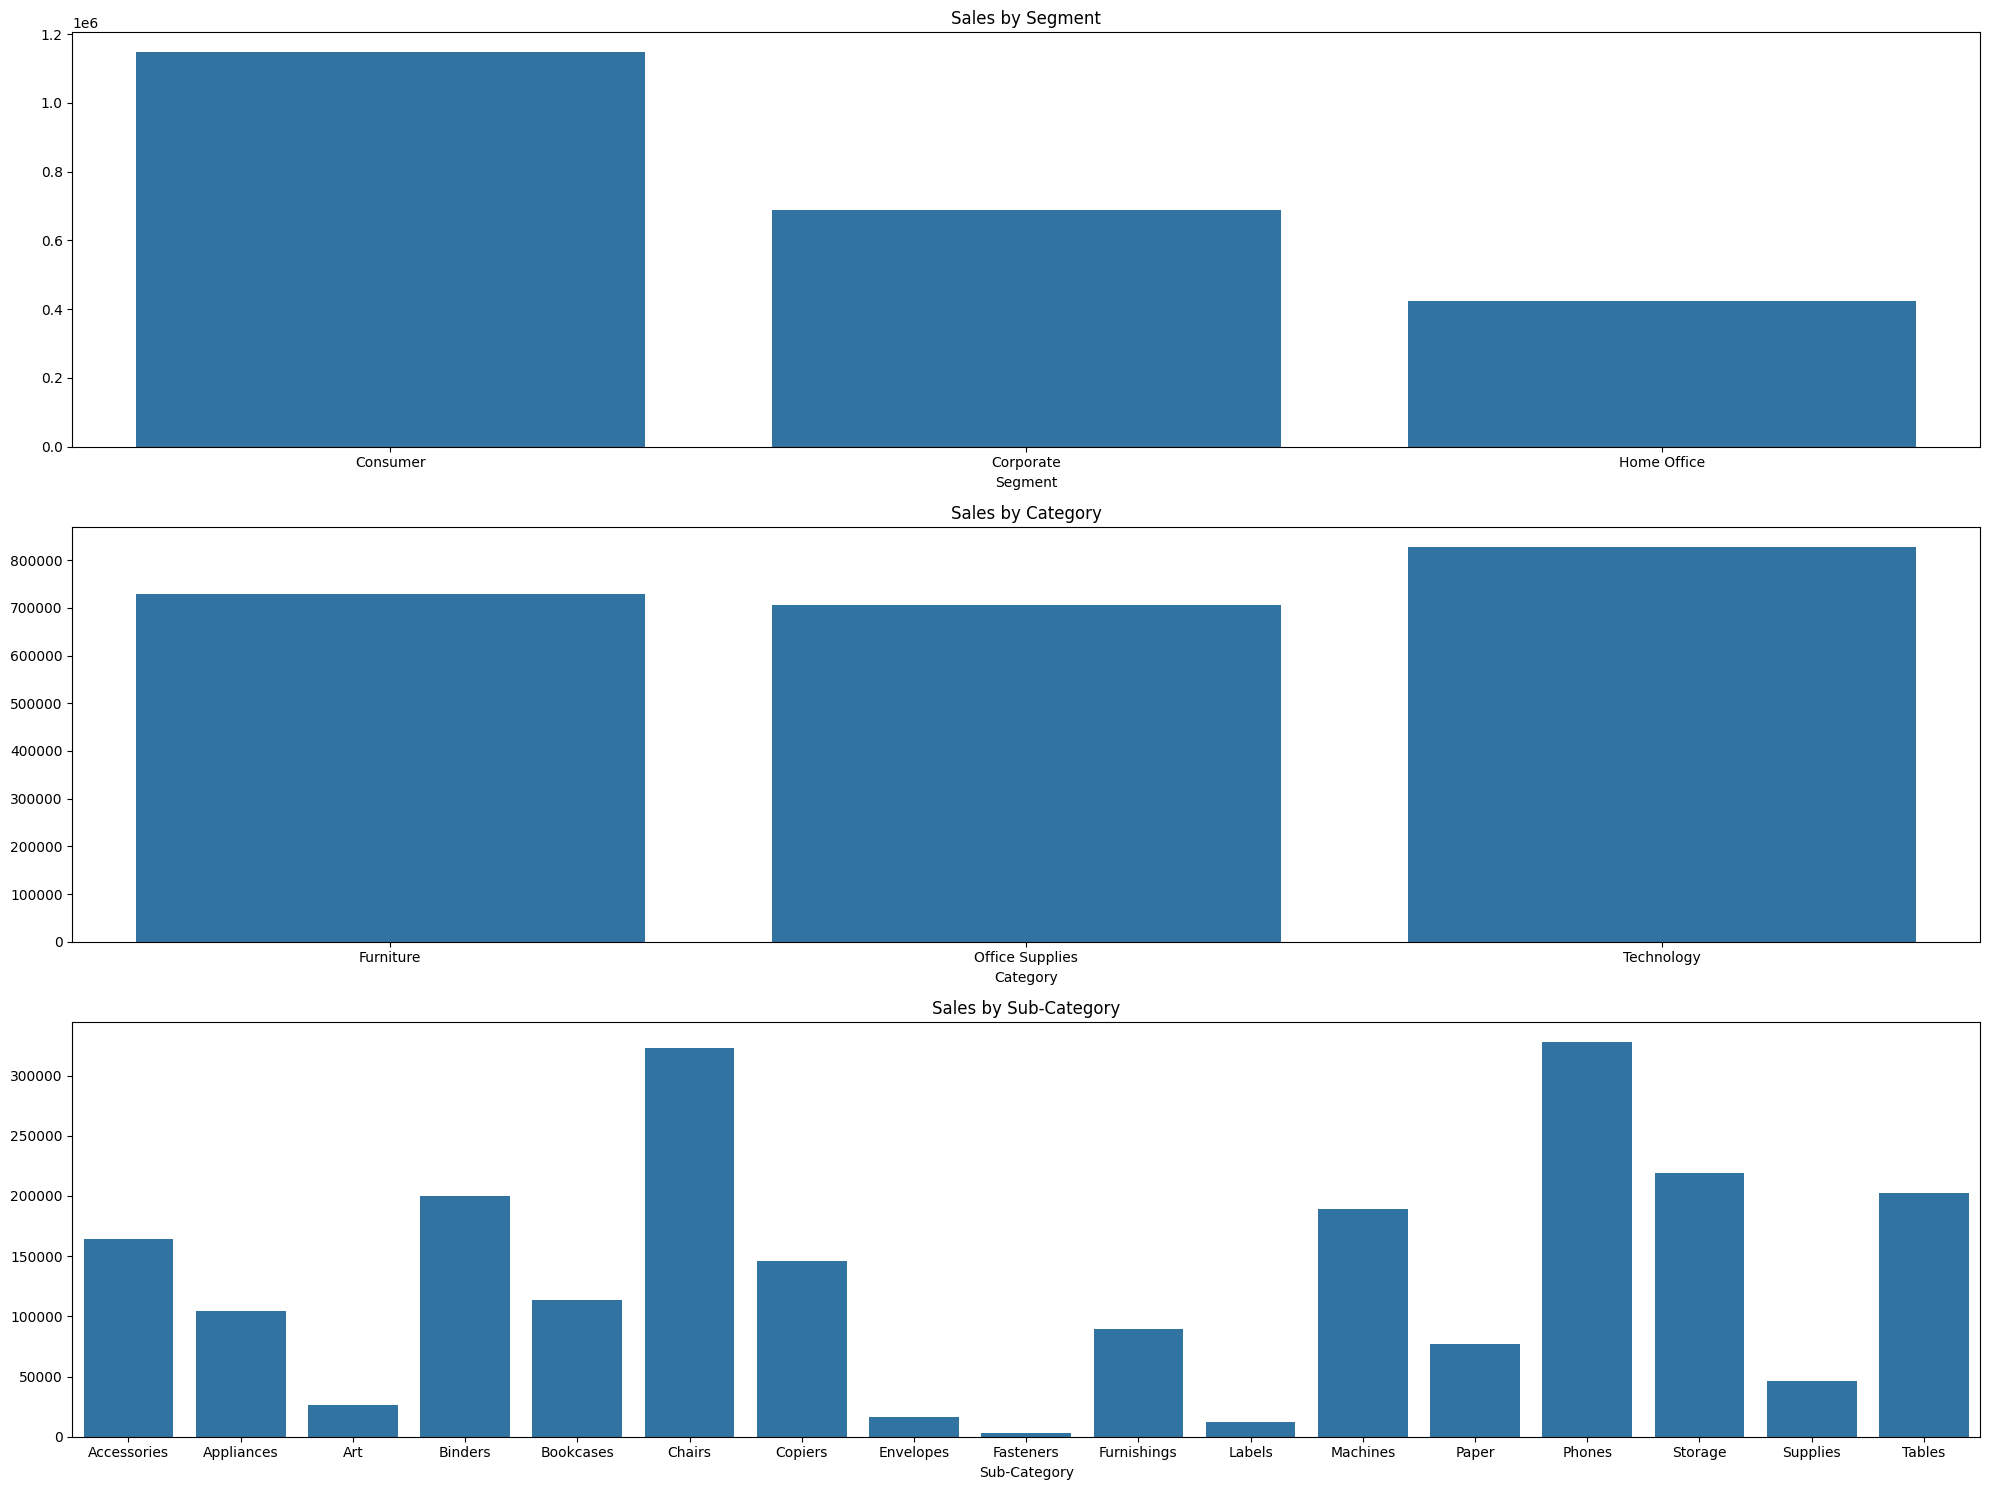

In [9]:
total_sales = sales_data['Sales'].sum()
sales_segment = sales_data.groupby('Segment')['Sales'].sum()
sales_category = sales_data.groupby('Category')['Sales'].sum()
sales_subcategory = sales_data.groupby('Sub-Category')['Sales'].sum()

fig, ax = plt.subplots(3, 1, figsize=(20, 15))

# Subplot 1: Sales by Segment
sns.barplot(x=sales_segment.index, y=sales_segment.values, ax=ax[0])
ax[0].set_title('Sales by Segment')

# Subplot 2: Sales by Category
sns.barplot(x=sales_category.index, y=sales_category.values, ax=ax[1])
ax[1].set_title('Sales by Category')

# Subplot 3: Sales by Sub-Category
sns.barplot(x=sales_subcategory.index, y=sales_subcategory.values, ax=ax[2])
ax[2].set_title('Sales by Sub-Category')

plt.tight_layout()
plt.show()

In [10]:
consumer_sales = sales_data[sales_data["Segment"] == "Consumer"]["Sales"].sum() / total_sales * 100
chair_sales = sales_data[sales_data["Sub-Category"] == "Chairs"]["Sales"].sum() / total_sales * 100
phone_sales = sales_data[sales_data["Sub-Category"] == "Phones"]["Sales"].sum() / total_sales * 100

print(f"Consumer Sales: {consumer_sales:.2f}%")
print(f"Chairs and Phones Sales: {(chair_sales + phone_sales):.2f}%")

Consumer Sales: 50.76%
Chairs and Phones Sales: 28.77%


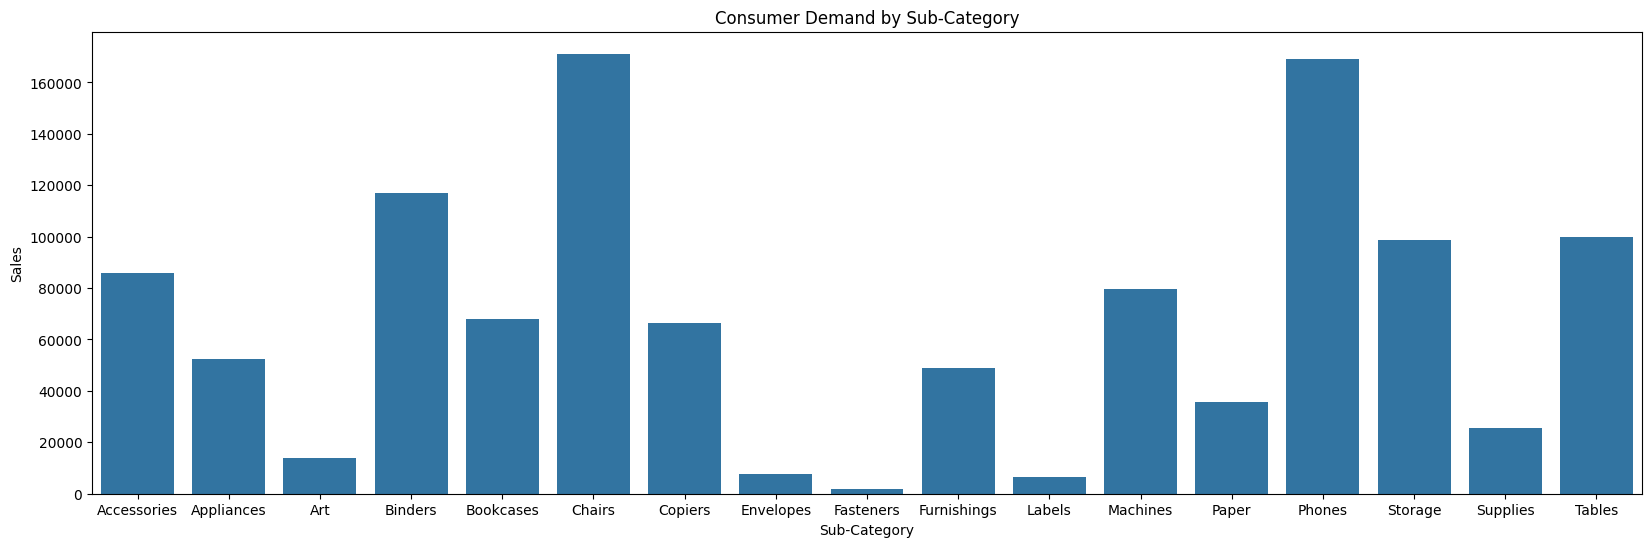

In [11]:
consumer_demands = sales_data[sales_data["Segment"] == "Consumer"].groupby("Sub-Category")["Sales"].sum()
plt.figure(figsize=(20, 6))
sns.barplot(x=consumer_demands.index, y=consumer_demands.values)
plt.title("Consumer Demand by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.show()


In [13]:
sales_data[(sales_data["Segment"] == "Consumer") &
           ((sales_data["Sub-Category"] == "Chairs") | (sales_data["Sub-Category"] == "Phones"))]["Sales"].sum() / (sales_data[sales_data['Segment'] == "Consumer"]["Sales"].sum()) * 100

np.float64(29.65041640300062)

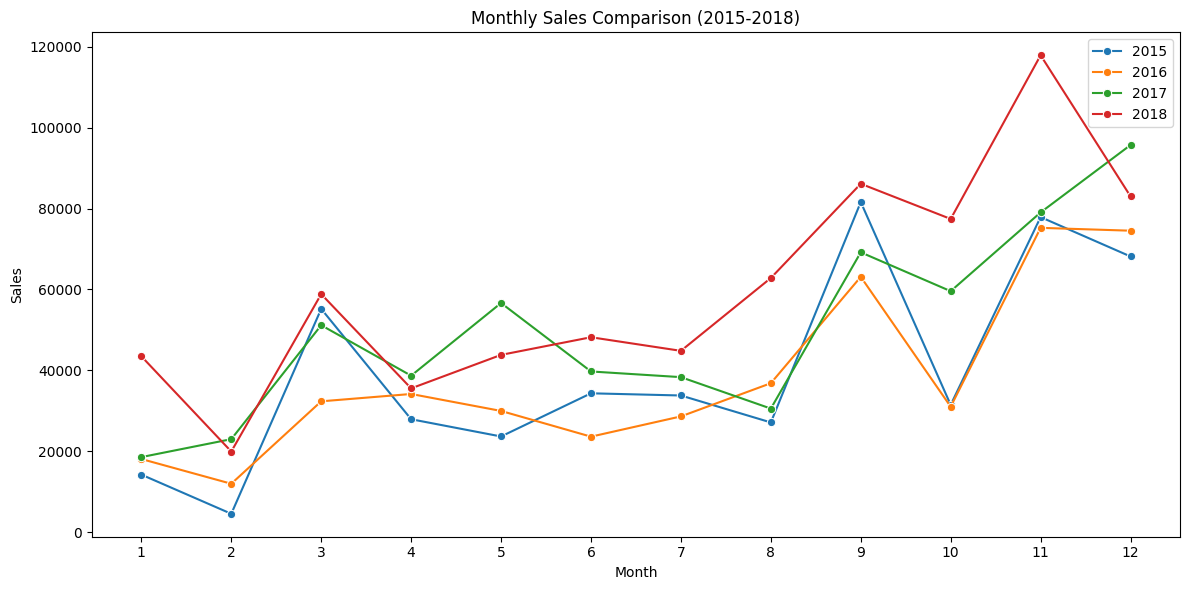

In [12]:
sales_2015 = sales_data[sales_data["Order Date"].dt.year == 2015].groupby(sales_data["Order Date"].dt.month)["Sales"].sum().reset_index()
sales_2016 = sales_data[sales_data["Order Date"].dt.year == 2016].groupby(sales_data["Order Date"].dt.month)["Sales"].sum().reset_index()
sales_2017 = sales_data[sales_data["Order Date"].dt.year == 2017].groupby(sales_data["Order Date"].dt.month)["Sales"].sum().reset_index()
sales_2018 = sales_data[sales_data["Order Date"].dt.year == 2018].groupby(sales_data["Order Date"].dt.month)["Sales"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_2015["Order Date"], y=sales_2015["Sales"], label="2015", marker="o")
sns.lineplot(x=sales_2016["Order Date"], y=sales_2016["Sales"], label="2016", marker="o")
sns.lineplot(x=sales_2017["Order Date"], y=sales_2017["Sales"], label="2017", marker="o")
sns.lineplot(x=sales_2018["Order Date"], y=sales_2018["Sales"], label="2018", marker="o")
plt.title("Monthly Sales Comparison (2015-2018)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(1, 13))

plt.legend()
plt.tight_layout()
plt.show()